In [1]:
import numpy as np
from matplotlib import pyplot as plt

import astropy.units as u
from astropy.constants import c

from lenstronomy.Data.coord_transforms import Coordinates
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Data.pixel_grid import PixelGrid
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
import lenstronomy.Util.image_util as image_util
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Analysis.lens_profile import LensProfileAnalysis

import os
import copy

cwd = os.getcwd()
cwd

'/Users/admin/Documents/SED_inferred_color_images'

In [2]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams.update({'figure.autolayout': True})


plt.rc('text', usetex=False)
plt.rc('font', family='serif',size=15)
plt.rc('font',size=15)
plt.rc('axes', linewidth=1.5) # change back to 1.5
plt.rc('axes', labelsize=20) # change back to 10
plt.rc('xtick', labelsize=18, direction='in')
plt.rc('ytick', labelsize=18, direction='in')
plt.rc('legend', fontsize=15) # change back to 7

# setting xtick parameters:

plt.rc('xtick.major',size=10,pad=4)
plt.rc('xtick.minor',size=5,pad=4)

plt.rc('ytick.major',size=10)
plt.rc('ytick.minor',size=5)

### Set Cosmological Model

In [3]:
from astropy.cosmology import FlatLambdaCDM

Om = 0.3
custom_cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Om0=Om, Ob0=0.05)

z_l = 0.5
z_s = 1.5

lens_luminosity_distance = custom_cosmo.luminosity_distance(z_l).to(u.pc).value
source_luminosity_distance = custom_cosmo.luminosity_distance(z_s).to(u.pc).value

In [4]:
zeropoints = np.array([25.74, 29.8, 30.0, 29.9])

### Load Model Parameters

In [5]:
import pickle

input_name = 'main_3'

# load kwargs
with open(f'{cwd}/../creating_spiral_images/{input_name}/kwargs.pkl', 'rb') as f:
    data = pickle.load(f)
    kwargs_params_in, kwargs_model_in, multiband_list_in = data['params'], data['models'], data['multiband_list']

'''kwargs_model_in['lens_model_list'] = ['SIE'] + [kwargs_model_in['lens_model_list'][2]]

kwargs_params_in['kwargs_lens'] = [{'theta_E': 1.8, 'center_x': kwargs_params_in['kwargs_lens'][0]['center_x'], 'center_y': kwargs_params_in['kwargs_lens'][0]['center_y'],
                                    'e1': kwargs_params_in['kwargs_lens'][0]['e1'], 'e2': kwargs_params_in['kwargs_lens'][0]['e2']}
                                   ] + [kwargs_params_in['kwargs_lens'][2]]
kwargs_params_in['kwargs_lens_light'] = [{
    'amp': 1,
    'R_sersic': 2.5,
    'n_sersic': 4,
    'e1': kwargs_params_in['kwargs_lens_light'][0]['e1'],
    'e2': kwargs_params_in['kwargs_lens_light'][0]['e2'],
    'center_x': kwargs_params_in['kwargs_lens_light'][0]['center_x'],
    'center_y': kwargs_params_in['kwargs_lens_light'][0]['center_y']
}]

kwargs_params_in['kwargs_source'][0]['R_sersic'] = 0.2
kwargs_params_in['kwargs_source'][0]['n_sersic'] = 1
'''
print(f'Currently loaded model is {input_name}')
kwargs_model_in['source_light_model_list'], kwargs_params_in['kwargs_lens_light'], kwargs_params_in['kwargs_lens'], kwargs_params_in['kwargs_source']

Currently loaded model is main_3


(['SERSIC_ELLIPSE'],
 [{'amp': 4.723571557984374,
   'R_sersic': 2.5,
   'n_sersic': 1.5,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2}],
 [{'theta_E': 1.8,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2},
  {'theta_E': 0.4,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104}],
 [{'amp': 50.23992760883659,
   'R_sersic': 0.2,
   'n_sersic': 4.0,
   'center_x': 0.4,
   'center_y': 0.0,
   'e1': -0.5,
   'e2': -0.6}])

In [6]:
def comp_theta_E(lens_model_list, kwargs_lens, lens_redshift_list, z_s):

    lens_analysis_main_lens = LensProfileAnalysis(
            LensModel(
                lens_model_list=lens_model_list,
                lens_redshift_list=lens_redshift_list,
                z_source=z_s,
                multi_plane=False,  #  multi_plane=True does not work here
            )
        )
    
    theta_E = lens_analysis_main_lens.effective_einstein_radius(kwargs_lens,
                                                                    r_min=0.01,
                                                                    r_max=100,
                                                                    num_points=10
                                                                    )
    return theta_E

comp_theta_E(kwargs_model_in['lens_model_list'], kwargs_params_in['kwargs_lens'], [z_l for i in range(len(kwargs_model_in['lens_model_list']))], z_s)

1.7562535063790106

### Define Image Parameters

In [15]:
exp_time = 2422
bkg_rms = 0.04

NIR_pixel_scale = 0.3
NIR_num_pix = 50
NIR_psf_fwhm = [0.475, 0.504, 0.542]

VIS_pixel_scale = 0.1
VIS_num_pix = int(NIR_num_pix * round(NIR_pixel_scale / VIS_pixel_scale))
VIS_psf_fwhm = 0.203

In [16]:
kwargs_psf_VIS = {
    'psf_type': 'GAUSSIAN', 
    'fwhm': VIS_psf_fwhm, 
    'pixel_size': VIS_pixel_scale, 
    'truncation': 6
    }
kwargs_psf_NIR_J = {
    'psf_type': 'GAUSSIAN', 
    'fwhm': NIR_psf_fwhm[1], 
    'pixel_size': NIR_pixel_scale, 
    'truncation': 6
    }

VIS_psf_class = PSF(**kwargs_psf_VIS)
NIR_J_psf_class = PSF(**kwargs_psf_NIR_J)

### Construct Model Without Lens Light and unit scaling of source light profile

In [17]:
nll_kwargs_params = copy.deepcopy(kwargs_params_in)
nll_kwargs_model = copy.deepcopy(kwargs_model_in)
nll_multiband_list = copy.deepcopy(multiband_list_in)

nll_kwargs_params['kwargs_lens_light'] = []
nll_kwargs_model['lens_light_model_list'] = []

nll_kwargs_params['kwargs_source'][0]['amp'] = 1

#### Create Redshift lists

In [18]:
z_l_list = [z_l for i in range(len(kwargs_model_in['lens_model_list']))]
z_s_list = [z_s for i in range(len(kwargs_model_in['source_light_model_list']))]
z_l_list, z_s_list

([0.5, 0.5], [1.5])

In [19]:
def create_image_data(kwargs_model, kwargs_params, pixel_scale, num_pixels, exp_time, bkg_rms, psf_fwhm, 
                      lens_redshifts, source_redshifts, cosmo=custom_cosmo, add_noise=True):
    
    kwargs_data = {
        'background_rms': bkg_rms,  # rms of background noise
        'exposure_time': exp_time,  # exposure time (or a map per pixel)
        'ra_at_xy_0': -num_pixels*pixel_scale/2,  # RA at (0,0) pixel
        'dec_at_xy_0': -num_pixels*pixel_scale/2,  # DEC at (0,0) pixel
        'transform_pix2angle': np.array([[pixel_scale, 0], [0, pixel_scale]]),  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
        'image_data': np.zeros((num_pixels, num_pixels))
    }

    kwargs_psf = {
        'psf_type': 'GAUSSIAN', 
        'fwhm': psf_fwhm, 
        'pixel_size': pixel_scale, 
        'truncation': 12
        }
    
    kwargs_numerics = {'supersampling_factor': 4, 'supersampling_convolution': False}

    coords = Coordinates(kwargs_data['transform_pix2angle'], kwargs_data['ra_at_xy_0'], kwargs_data['dec_at_xy_0'])
    kwargs_pixel = {'nx': num_pixels, 'ny': num_pixels,  # number of pixels per axis
                'ra_at_xy_0': kwargs_data['ra_at_xy_0'],  # RA at pixel (0,0)
                'dec_at_xy_0': kwargs_data['dec_at_xy_0'],  # DEC at pixel (0,0)
                'transform_pix2angle': kwargs_data['transform_pix2angle']} 

    data_class = ImageData(**kwargs_data)
    psf_class = PSF(**kwargs_psf)

    pixel_grid = PixelGrid(**kwargs_pixel)

    multi_band_pixel_grids = [PixelGrid(**kwargs_pixel)]

    lens_model_class = LensModel(kwargs_model['lens_model_list'], lens_redshift_list=lens_redshifts, cosmo=cosmo)
    source_model_class = LightModel(kwargs_model['source_light_model_list'], source_redshift_list=source_redshifts)
    lens_light_model_class = LightModel(kwargs_model['lens_light_model_list'])

    image_model = ImageModel(data_class, psf_class, lens_model_class=lens_model_class, 
                        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                        kwargs_numerics=kwargs_numerics)
    
    # generate image
    image_model = image_model.image(kwargs_params['kwargs_lens'], kwargs_params['kwargs_source'], kwargs_lens_light=kwargs_params['kwargs_lens_light'], kwargs_ps=None)

    poisson_noise = image_util.add_poisson(image_model, exp_time=exp_time)
    background_noise = data_class.background_rms * np.random.normal(size=image_model.shape)

    if add_noise:
        image_real = image_model + poisson_noise #+ background_noise
    else:
        image_real = image_model

    data_class.update_data(image_real)
    kwargs_data['image_data'] = image_real

    return kwargs_data

#### Create image

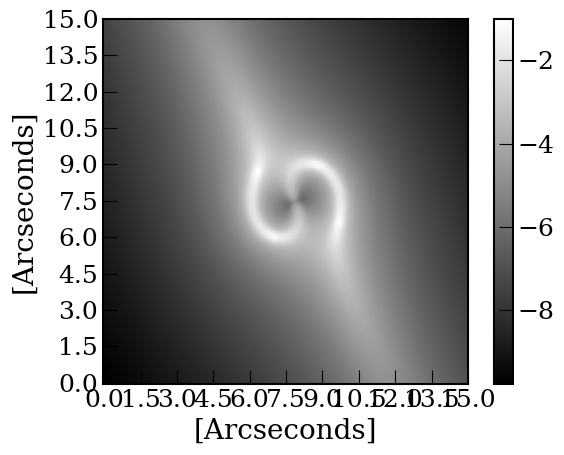

In [20]:
nll_pixels = 150

nll_kwargs_data = create_image_data(
    nll_kwargs_model, nll_kwargs_params, VIS_pixel_scale, nll_pixels, exp_time, bkg_rms, VIS_psf_fwhm,
    lens_redshifts=z_l_list, source_redshifts=z_s_list, cosmo=custom_cosmo, add_noise=False
)

plt.imshow(np.log10(np.abs(nll_kwargs_data['image_data'])), origin='lower', cmap='gray')
plt.xticks(np.linspace(0, nll_pixels, 11), labels=np.round(np.linspace(0, nll_pixels*VIS_pixel_scale, 11), 1))
plt.yticks(np.linspace(0, nll_pixels, 11), labels=np.round(np.linspace(0, nll_pixels*VIS_pixel_scale, 11), 1))

plt.xlabel('[Arcseconds]')
plt.ylabel('[Arcseconds]')

plt.colorbar()
plt.show()

In [21]:
total_unit_source_flux = np.sum(nll_kwargs_data['image_data'])
total_unit_source_flux


8.563138297071848

In [22]:
from scipy.special import gamma

def sersic_total_flux(R_sersic, n_sersic, e1 ,e2):
    k_n = 1.9992 * n_sersic - 0.3271  # approximate
    q = (1-np.sqrt(e1**2 + e2**2)) / (1+np.sqrt(e1**2 + e2**2))
    return 2 * np.pi * R_sersic**2 * q * n_sersic * np.exp(k_n) * gamma(2 * n_sersic) / k_n**(2 * n_sersic)

total_unit_lens_flux = sersic_total_flux(
    kwargs_params_in['kwargs_lens_light'][0]['R_sersic'], 
    kwargs_params_in['kwargs_lens_light'][0]['n_sersic'], 
    kwargs_params_in['kwargs_lens_light'][0]['e1'], 
    kwargs_params_in['kwargs_lens_light'][0]['e2']
)
total_unit_source_flux = sersic_total_flux(
    kwargs_params_in['kwargs_source'][0]['R_sersic'], 
    kwargs_params_in['kwargs_source'][0]['n_sersic'], 
    kwargs_params_in['kwargs_source'][0]['e1'], 
    kwargs_params_in['kwargs_source'][0]['e2']
)
total_unit_lens_flux, total_unit_source_flux

(56.697313295297626, 0.11146444345115833)

In [23]:
'''sums = []
image_sizes = np.sqrt(np.linspace(5**2, 250**2, 20))

for i in image_sizes:
    data, _, _ = create_image_data(
        nll_kwargs_model, nll_kwargs_params, VIS_pixel_scale, int(i), exp_time, bkg_rms, VIS_psf_fwhm,
        lens_redshifts=z_l_list, source_redshifts=z_s_list, cosmo=custom_cosmo, add_noise=False
    )
    sums.append(np.sum(data['image_data']))'''

'''plt.plot(np.log10(np.abs(np.diff(sums))))
plt.show()'''

'plt.plot(np.log10(np.abs(np.diff(sums))))\nplt.show()'

### Load SEDs

In [24]:
SED_directory = cwd + '/../euclid_color_profiles/swire_library_as_csv/'

Ell_SED_rest = np.loadtxt(SED_directory + 'Ell13_template_norm.csv', unpack=True)
S0_SED_rest = np.loadtxt(SED_directory + 'SA_template_norm.csv', unpack=True)

test_star_forming = np.loadtxt('../creating_SED_from_stellar_pop/sed_observed_test.csv', unpack=True, comments='#')
S0_SED_rest = test_star_forming

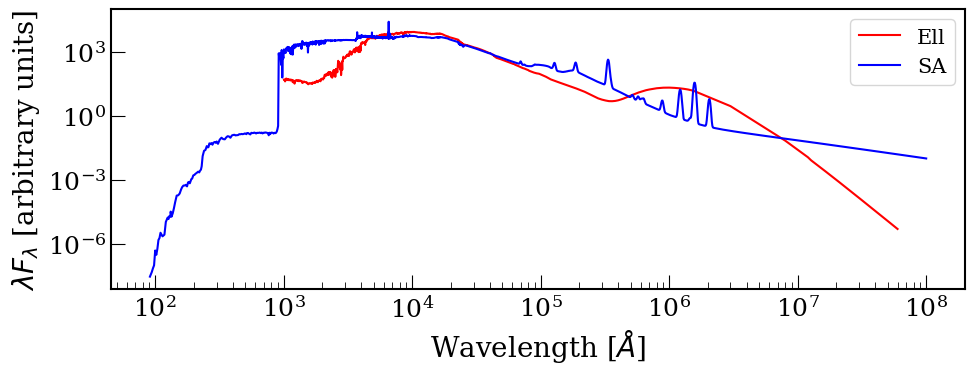

In [25]:
plt.figure(figsize=(10,4))
plt.plot(Ell_SED_rest[0], Ell_SED_rest[1] * Ell_SED_rest[0], label='Ell', c='r')
plt.plot(S0_SED_rest[0], S0_SED_rest[1] * S0_SED_rest[0], label='SA', c='b')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel(r'$\lambda F_{\lambda}$ [arbitrary units]')
plt.legend()
plt.show()

### Redshift SEDs

In [26]:
def redshift_lambda(lambda_in, flux_density_in, z, cosmology):
    lambda_out = lambda_in * (z + 1)
    flux_density_out = flux_density_in / ((1+z))# * 2 * np.pi * cosmology.luminosity_distance(z))

    return np.array((lambda_out, flux_density_out))

Ell_SED_obs = redshift_lambda(Ell_SED_rest[0], Ell_SED_rest[1], z_l, custom_cosmo)
S0_SED_obs = redshift_lambda(S0_SED_rest[0], S0_SED_rest[1], z_s, custom_cosmo)

In [27]:
import photometry

pbs = [{'file': 'VIS.Euclid.pb', 'outCol': 'TU_Fnu_VIS', 'band': None, 'name': 'VIS'},
       {'file': 'Y_NISP.Euclid.pb', 'outCol': 'TU_Fnu_NIR_Y', 'band': None, 'name': 'NIR_Y'},
       {'file': 'J_NISP.Euclid.pb', 'outCol': 'TU_Fnu_NIR_J', 'band': None, 'name': 'NIR_J'},
       {'file': 'H_NISP.Euclid.pb', 'outCol': 'TU_Fnu_NIR_H', 'band': None, 'name': 'NIR_H'}]

for i, pb in enumerate(pbs):
    pbs[i]['band'] = photometry.Passband(file=pbs[i]['file'])

temp = [np.array([pb['band'].lam(unit=u.Angstrom).value, pb['band'].y]) for pb in pbs]

Euclid_VIS_mask = 3450. < temp[0][0]

filter_throughputs = [np.array([temp[0][0][Euclid_VIS_mask], temp[0][1][Euclid_VIS_mask]])]
for filter in temp[1:]:
    filter_throughputs.append(filter)

In [28]:
from scipy.integrate import trapezoid

def get_ab_mag(SED: np.ndarray, filter_throughput: np.ndarray, interp_method=np.interp, intergrate_method=trapezoid):
    
    # interpolate filter_throughput to SED wavelengths
    if not np.all(np.diff(filter_throughput[0]) > 0):
        raise ValueError('Filter wavelengths are not strictly increasing')
    
    # create mask of SED wavelengths where throughput exists


    interped_filter_throughput = interp_method(SED[0], filter_throughput[0], filter_throughput[1], left=0, right=0)

    f_lambda = intergrate_method(y=interped_filter_throughput * SED[1] * SED[0], x=SED[0]) / intergrate_method(y=interped_filter_throughput * SED[0], x=SED[0])
    lambda_p_2 = intergrate_method(y=interped_filter_throughput * SED[0], x=SED[0]) / intergrate_method(y=interped_filter_throughput / SED[0], x=SED[0])

    return -2.5 * np.log10(f_lambda) - 2.5 * np.log10(lambda_p_2 / c.to(u.Angstrom / u.s).value) - 48.6

def get_weighted_mean_flux(SED: np.ndarray, filter_throughput: np.ndarray, interp_method=np.interp, intergrate_method=trapezoid):
    # interpolate filter_throughput to SED wavelengths
    if not np.all(np.diff(filter_throughput[0]) > 0):
        raise ValueError('Filter wavelengths are not strictly increasing')

    interped_filter_throughput = interp_method(SED[0], filter_throughput[0], filter_throughput[1], left=0, right=0)

    f_lambda = intergrate_method(y=interped_filter_throughput * SED[1] * SED[0], x=SED[0]) / intergrate_method(y=interped_filter_throughput * SED[0], x=SED[0])
    
    return f_lambda

In [29]:
c.to(u.Angstrom / u.s).value

2.9979245799999995e+18

In [30]:
# Scale SEDs to have desired magnitude in VIS band
target_mags = np.array([21, 23.5])

VIS_mags = np.array([get_ab_mag(Ell_SED_obs, filter_throughputs[0]), get_ab_mag(S0_SED_obs, filter_throughputs[0])])

scaling_factors = 10 ** (-0.4 * (target_mags - VIS_mags))

Ell_SED_obs_scaled = np.array([Ell_SED_obs[0], scaling_factors[0] * Ell_SED_obs[1]])
S0_SED_obs_scaled =np.array([S0_SED_obs[0],  scaling_factors[1] * S0_SED_obs[1]])

scaling_factors, VIS_mags

(array([1.55250529e-17, 1.78014771e-18]), array([-21.02241728, -20.8738599 ]))

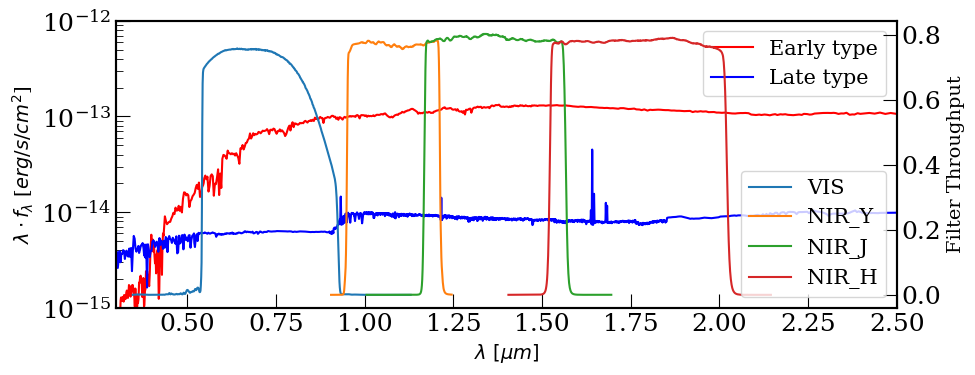

In [31]:
fig, ax1 = plt.subplots(figsize=(10,4))

fontsize = 14

ax1.plot(Ell_SED_obs_scaled[0]*1e-4, Ell_SED_obs_scaled[0] * Ell_SED_obs_scaled[1], label='Early type', c='r')
ax1.plot(S0_SED_obs_scaled[0]*1e-4, S0_SED_obs_scaled[0] * S0_SED_obs_scaled[1], label='Late type', c='b')

ax1.set_yscale('log')
#ax1.set_xscale('log')

xlims = (3.0e-1, 2.5e0)
ax1.set_xlim(xlims)
'''ax1.set_ylim((np.min([np.min(Ell_SED_obs_scaled[0][Ell_SED_obs_scaled[0]<xlims[1]] * Ell_SED_obs_scaled[1][Ell_SED_obs_scaled[0]<xlims[1]]), 
                      np.min(S0_SED_obs_scaled[0][S0_SED_obs_scaled[0]<xlims[1]] * S0_SED_obs_scaled[1][S0_SED_obs_scaled[0]<xlims[1]])])/1.5, 
              np.max([np.max(Ell_SED_obs_scaled[0] * Ell_SED_obs_scaled[1]), np.max(S0_SED_obs_scaled[0] * S0_SED_obs_scaled[1])])*1.5))'''
ax1.set_ylim((1e-15, 1e-12))

ax1.set_xlabel(r'$\lambda\ [\mu m]$', fontsize=fontsize)
ax1.set_ylabel(r'$\lambda \cdot f_{\lambda}$ [$erg/s/cm^2$]', fontsize=fontsize)

ax1.legend()

ax2 = ax1.twinx()

for i, filter in enumerate(filter_throughputs):
    ax2.plot(filter[0]*1e-4, filter[1], label=pbs[i]['name'])

ax2.set_ylabel('Filter Throughput', fontsize=fontsize)
ax2.legend(loc='lower right')
#ax2.legend(loc='lower right')
plt.savefig('SEDs_with_throughputs.png', dpi=300)
plt.show()

In [32]:
Ell_mean_fluxes = np.array([get_weighted_mean_flux(Ell_SED_obs_scaled, throughput) for throughput in filter_throughputs])
S0_mean_fluxes = np.array([get_weighted_mean_flux(S0_SED_obs_scaled, throughput) for throughput in filter_throughputs])

magnification_factor = 11.194415299062403

total_unit_source_flux_magged = total_unit_source_flux * magnification_factor


lens_amps = Ell_mean_fluxes / total_unit_lens_flux# * 10 / 2.56
source_amps = S0_mean_fluxes / total_unit_source_flux_magged 
amplitudes= np.array([lens_amps, source_amps])

In [33]:
amplitudes, S0_mean_fluxes / Ell_mean_fluxes

(array([[1.51504166e-19, 1.73801742e-19, 1.60039760e-19, 1.19050931e-19],
        [6.88358157e-19, 6.94672968e-19, 5.04893586e-19, 3.78857439e-19]]),
 array([0.09999198, 0.08796331, 0.06943001, 0.07003551]))

In [34]:
import image_creator

SED_paths = {'source': '/Users/admin/Documents/creating_SED_from_stellar_pop/sed_observed_test.csv', 'lens': SED_directory + 'SA_template_norm.csv'}

color_maker = image_creator.SED_color_calculator(SED_paths, cosmology=custom_cosmo, target_mags=target_mags)

amps = color_maker.get_amplitudes({'lens': 21, 'source': 23.5}, kwargs_model_in, kwargs_params_in, {'lens': 0.5, 'source': 2.5})
amplitudes = np.array((amps['lens'], amps['source']))/ 10 **(-0.4 * 21.688745117447276)
scaling = amplitudes[0, 0]
amplitudes *= 1 / scaling
'''/ 10 **(-0.4*(19.688745117447283))

amplitudes[0] /= 10 ** (-0.4 * zeropoints)
amplitudes[1] /= 10 ** (-0.4 * zeropoints)'''

amplitudes

{'kwargs_lens': [{'theta_E': 1.8, 'center_x': 0.3686891993185043, 'center_y': -0.040460506267520104, 'e1': -0.1, 'e2': 0.2}, {'theta_E': 0.4, 'center_x': 0.3686891993185043, 'center_y': -0.040460506267520104}], 'kwargs_source': [{'amp': 50.23992760883659, 'R_sersic': 0.2, 'n_sersic': 4.0, 'center_x': 0.4, 'center_y': 0.0, 'e1': -0.5, 'e2': -0.6}], 'kwargs_lens_light': [{'amp': 4.723571557984374, 'R_sersic': 2.5, 'n_sersic': 1.5, 'center_x': 0.3686891993185043, 'center_y': -0.040460506267520104, 'e1': -0.1, 'e2': 0.2}], 'kwargs_ps': [], 'kwargs_special': {}, 'kwargs_extinction': [], 'kwargs_tracer_source': []}
lens ab mag raw sed -21.057336305968576
source ab mag raw sed -20.74561460621779
scaling factors {'source': 2.003337670472839e-18, 'lens': 1.5033686085439563e-17}
42.057336305968576 44.245614606217785
lens ab mag scaled sed 20.999999999999993
source ab mag scaled sed 23.499999999999993
weighted mean fluxes {'lens': array([8.40430787e-18, 9.57714847e-18, 9.14737269e-18, 7.10057723e

array([[1.        , 1.13955231, 1.08841476, 0.84487353],
       [2.76311941, 2.13766882, 2.26668272, 1.85933938]])

In [38]:
-2.5 * np.log10(8.40430787e-18) - 48.6

-5.911254883190431

In [208]:
color_maker.compute_flux_ratio(kwargs_model_in, kwargs_params_in, filter_name='VIS', amplitudes={'lens': amplitudes[0,0], 'source': amplitudes[1,0]})
{'lens': amplitudes[0,0], 'source': amplitudes[1,0]}

computing lens flux in compute_flux_ratio
vis fluxes 0.31702117348966924 0.03170211734896705
vis ab mags 1.247279326926918 3.7472793269269133


{'lens': 1.0, 'source': 2.763119411050748}

In [209]:
kwargs_model_in['lens_light_model_list'][0] = 'SERSIC_ELLIPSE'

temp_params = copy.deepcopy(kwargs_params_in['kwargs_lens_light'])


VIS_kwargs_params = copy.deepcopy(kwargs_params_in)
NIR_Y_kwargs_params = copy.deepcopy(kwargs_params_in)
NIR_J_kwargs_params = copy.deepcopy(kwargs_params_in)
NIR_H_kwargs_params = copy.deepcopy(kwargs_params_in)

VIS_kwargs_params['kwargs_lens_light'][0]['amp'], VIS_kwargs_params['kwargs_source'][0]['amp'] = amplitudes[:, 0]
NIR_Y_kwargs_params['kwargs_lens_light'][0]['amp'], NIR_Y_kwargs_params['kwargs_source'][0]['amp'] = amplitudes[:, 1]
NIR_J_kwargs_params['kwargs_lens_light'][0]['amp'], NIR_J_kwargs_params['kwargs_source'][0]['amp'] = amplitudes[:, 2]
NIR_H_kwargs_params['kwargs_lens_light'][0]['amp'], NIR_H_kwargs_params['kwargs_source'][0]['amp'] = amplitudes[:, 3]

In [210]:
VIS_kwargs_data = create_image_data(kwargs_model_in, VIS_kwargs_params, VIS_pixel_scale, VIS_num_pix, exp_time, bkg_rms, VIS_psf_fwhm, z_l_list, z_s_list)
NIR_Y_kwargs_data = create_image_data(kwargs_model_in, NIR_Y_kwargs_params, NIR_pixel_scale, NIR_num_pix, exp_time, bkg_rms, NIR_psf_fwhm[0], z_l_list, z_s_list)
NIR_J_kwargs_data = create_image_data(kwargs_model_in, NIR_J_kwargs_params, NIR_pixel_scale, NIR_num_pix, exp_time, bkg_rms, NIR_psf_fwhm[1], z_l_list, z_s_list)
NIR_H_kwargs_data = create_image_data(kwargs_model_in, NIR_H_kwargs_params, NIR_pixel_scale, NIR_num_pix, exp_time, bkg_rms, NIR_psf_fwhm[2], z_l_list, z_s_list)

VIS_lens_flux = color_maker.compute_flux(VIS_kwargs_params, kwargs_model_in, VIS_kwargs_data, kwargs_psf_VIS, kwargs_numerics={'supersampling_factor': 3, 'supersampling_convolution': False}, to_compute=['lens'], z_lens=0.5)
VIS_source_lensed_flux = color_maker.compute_flux(VIS_kwargs_params, kwargs_model_in, VIS_kwargs_data, kwargs_psf_VIS, kwargs_numerics={'supersampling_factor': 3, 'supersampling_convolution': False}, to_compute=['source'], z_source=2.5, lens_image=True)
VIS_lens_flux, VIS_source_lensed_flux

(0.8626707389718852, 0.044005988228655715)

In [211]:
np.max(VIS_kwargs_data['image_data']), np.max(NIR_J_kwargs_data['image_data'])

(0.27804026819225, 0.7527747208666791)

In [212]:
-2.5 * np.log10(VIS_lens_flux) + 25.74, -2.5 * np.log10(VIS_source_lensed_flux) + 25.74

(25.90038733149207, 29.131220554369296)

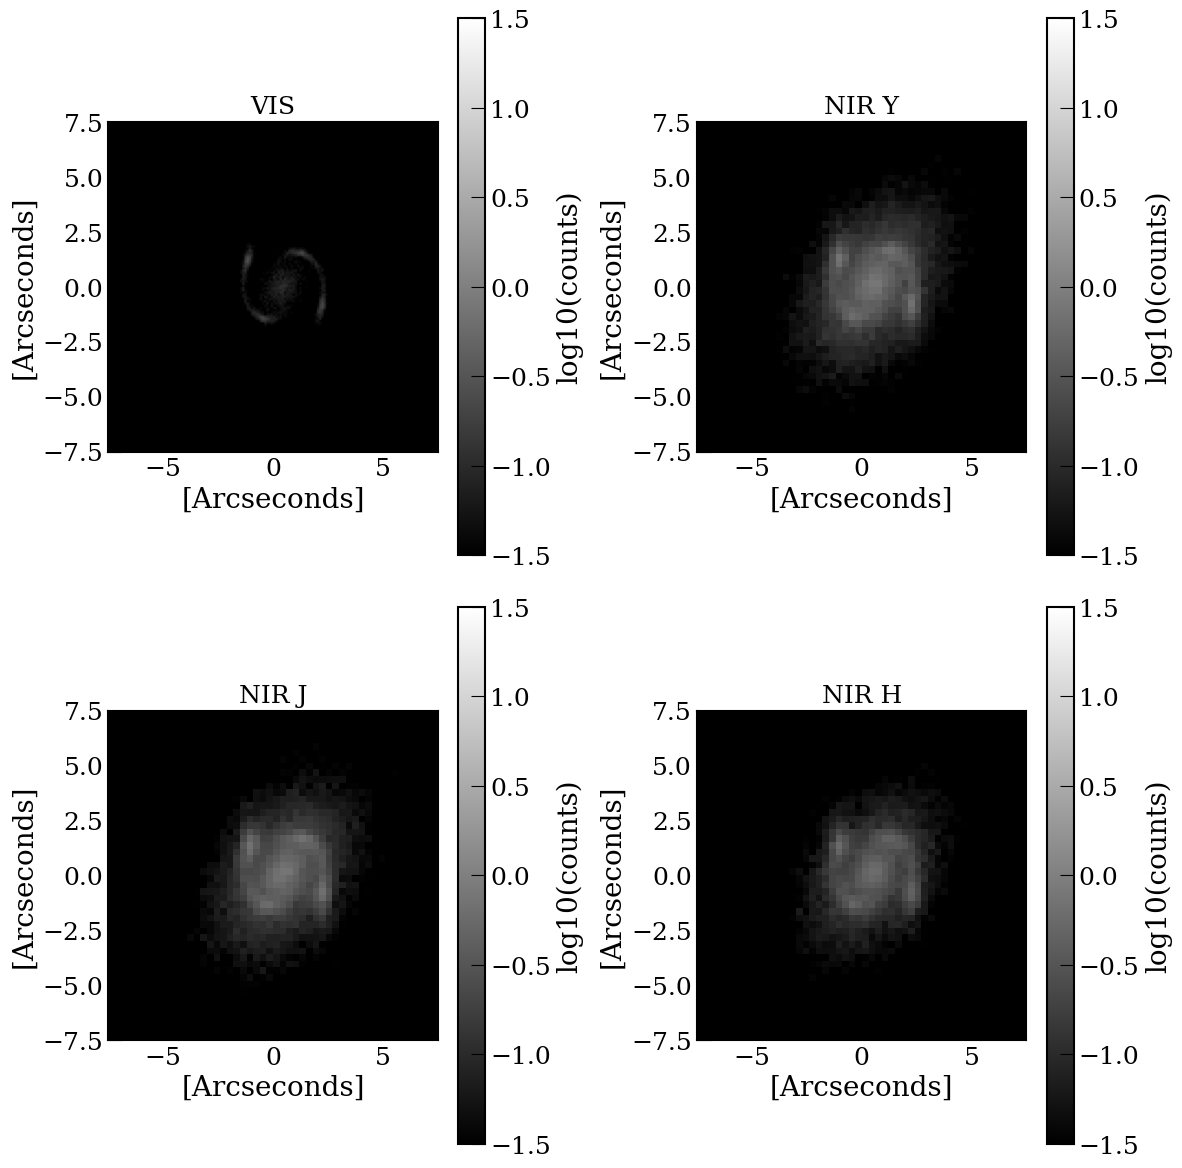

In [213]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

vmin, vmax = -1.5, 1.5
extent = (-.5*VIS_num_pix*VIS_pixel_scale, .5*VIS_num_pix*VIS_pixel_scale, -0.5*VIS_num_pix*VIS_pixel_scale, 0.5*VIS_num_pix*VIS_pixel_scale)


ax = axes[0, 0]
ax.imshow(np.log10(np.abs(VIS_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('VIS')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[0, 1]
ax.imshow(np.log10(np.abs(NIR_Y_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR Y')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 0]
ax.imshow(np.log10(np.abs(NIR_J_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR J')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 1]
ax.imshow(np.log10(np.abs(NIR_H_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR H')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

plt.show()

In [214]:
# convolve VIS to NIR resolution


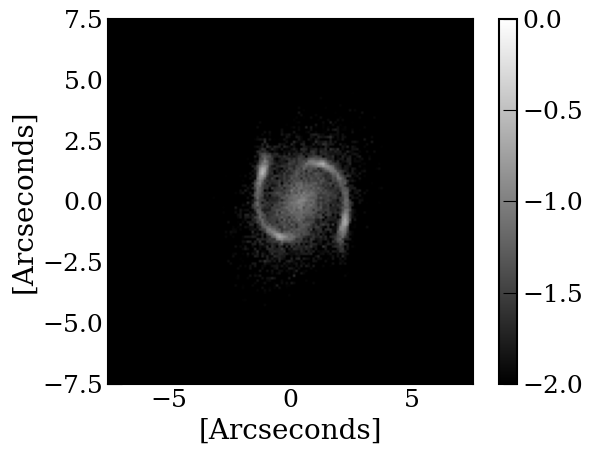

In [215]:
vmin, vmax = -2, -0.0

plt.imshow(np.log10(np.abs(VIS_kwargs_data['image_data'])), origin='lower', cmap='gray', vmin=vmin, vmax=vmax, extent=extent)
plt.xlabel('[Arcseconds]')
plt.ylabel('[Arcseconds]')
plt.colorbar()
plt.show()

In [216]:
from astropy.wcs import WCS

# create header object for VIS and NIR filters

VIS_coords = Coordinates(VIS_kwargs_data['transform_pix2angle'], VIS_kwargs_data['ra_at_xy_0'], VIS_kwargs_data['dec_at_xy_0'])
VIS_central_pix = np.array(VIS_kwargs_data['image_data'].shape) // 2

VIS_WCS = WCS(naxis=2)
VIS_WCS.wcs.ctype = ['RA---TAN', 'DEC--TAN']
VIS_WCS.wcs.cunit = ['deg', 'deg']
VIS_WCS.wcs.crval = VIS_coords.map_pix2coord(*VIS_central_pix)
VIS_WCS.wcs.crpix = VIS_central_pix
VIS_WCS.wcs.cdelt = [0.1/3600, 0.1/3600]

VIS_header = VIS_WCS.to_header()
VIS_header['naxis'] = 2
VIS_header['naxis1'], VIS_header['naxis2'] = VIS_kwargs_data['image_data'].shape
VIS_header['simple'] = True

NIR_coords = Coordinates(NIR_Y_kwargs_data['transform_pix2angle'], NIR_Y_kwargs_data['ra_at_xy_0'], NIR_Y_kwargs_data['dec_at_xy_0'])
NIR_central_pix = np.array(NIR_Y_kwargs_data['image_data'].shape) // 2

NIR_WCS = WCS(naxis=2)
NIR_WCS.wcs.ctype = ['RA---TAN', 'DEC--TAN']
NIR_WCS.wcs.cunit = ['deg', 'deg']
NIR_WCS.wcs.crval = NIR_coords.map_pix2coord(*NIR_central_pix)
NIR_WCS.wcs.crpix = NIR_central_pix
NIR_WCS.wcs.cdelt = [0.3/3600, 0.3/3600]

NIR_header = NIR_WCS.to_header()
NIR_header['naxis'] = 2
NIR_header['naxis1'], NIR_header['naxis2'] = NIR_Y_kwargs_data['image_data'].shape
NIR_header['simple'] = True

VIS_header['naxis1'], NIR_header['naxis1']

(150, 50)

In [217]:
# convolve VIS image to NIR resolution
from astropy.convolution import convolve_fft
VIS_convolved = convolve_fft(VIS_kwargs_data['image_data'], NIR_J_psf_class.kernel_pixel, normalize_kernel=True)

In [218]:
# resample VIS to NIR
from reproject import reproject_interp
VIS_image_resampled, VIS_footprint = reproject_interp((VIS_convolved, VIS_header), NIR_header)
VIS_image_resampled.shape

(50, 50)

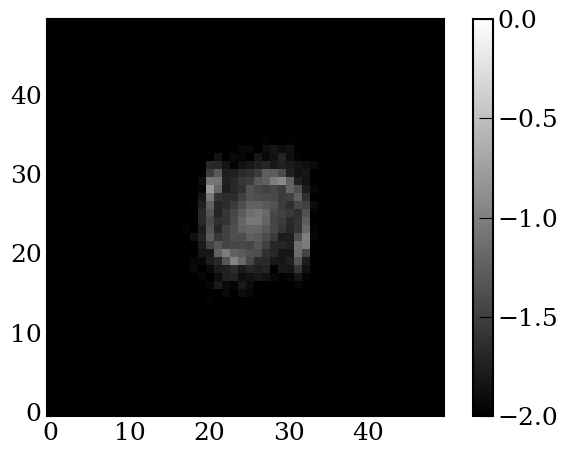

In [219]:
plt.imshow(np.log10(np.abs(VIS_image_resampled)), origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
plt.colorbar()
plt.show()

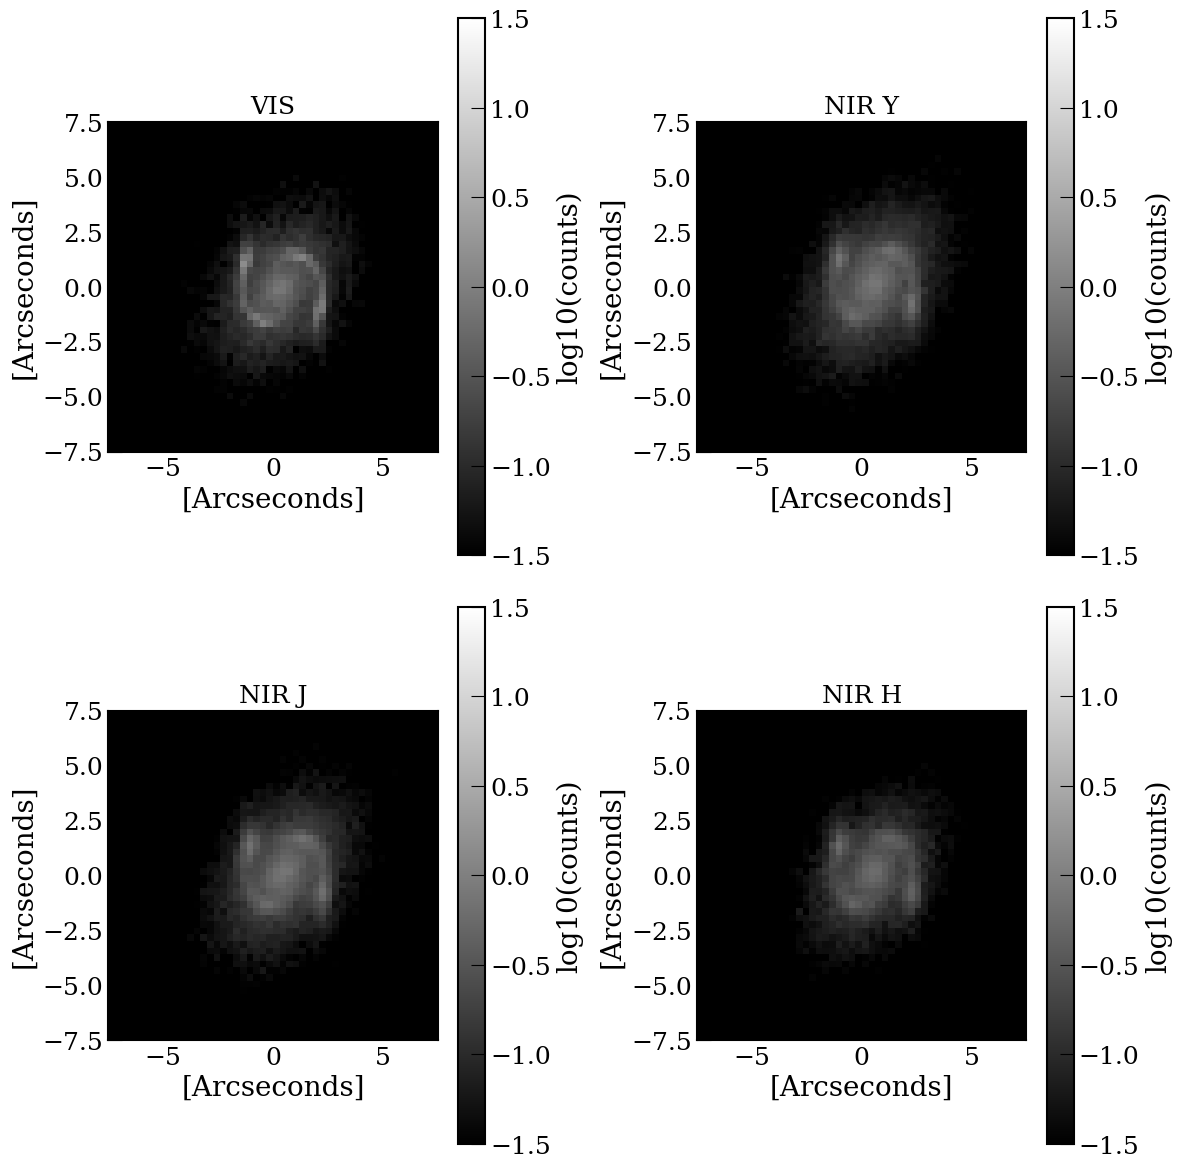

In [220]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

vmin, vmax = -1.5, 1.5
extent = (-.5*VIS_num_pix*VIS_pixel_scale, .5*VIS_num_pix*VIS_pixel_scale, -0.5*VIS_num_pix*VIS_pixel_scale, 0.5*VIS_num_pix*VIS_pixel_scale)


ax = axes[0, 0]
ax.imshow(np.log10(np.abs(VIS_image_resampled) * 9), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('VIS')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[0, 1]
ax.imshow(np.log10(np.abs(NIR_Y_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR Y')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 0]
ax.imshow(np.log10(np.abs(NIR_J_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR J')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 1]
ax.imshow(np.log10(np.abs(NIR_H_kwargs_data['image_data'])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR H')
ax.set_xlabel('[Arcseconds]')
ax.set_ylabel('[Arcseconds]')
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

plt.show()

In [221]:
from astropy.io import fits

path_to_noise_directory = cwd + '/../Euclid/cutouts/'
filters = ['VIS', 'NIR_Y', 'NIR_J', 'NIR_H']

noise_data = {}

for filter in filters:
    with fits.open(path_to_noise_directory + f'noise2_250_{filter}.fits') as hdul:
        noise_data[filter] = hdul[0].data * 10 ** (-0.4 * (zeropoints[filters.index(filter)]))

# resample VIS noise to NIR resolution
convolved = convolve_fft(noise_data['VIS'], VIS_psf_class.kernel_pixel, normalize_kernel=True)
noise_data['VIS_resampled'], _ = reproject_interp((convolved, VIS_header), NIR_header)
noise_data['NIR_Y_resampled'], _ = reproject_interp((noise_data['NIR_Y'], NIR_header), NIR_header)
noise_data['NIR_J_resampled'], _ = reproject_interp((noise_data['NIR_J'], NIR_header), NIR_header)
np.std(noise_data['NIR_J']), 10 ** (-0.4 * (25))

(8.4699495e-13, 1e-10)

In [222]:
# create VIS image in NIR format
'''
def create_image_data(kwargs_model, kwargs_params, pixel_scale, num_pixels, exp_time, bkg_rms, psf_fwhm, 
                      lens_redshifts, source_redshifts, cosmo=custom_cosmo, add_noise=True):
'''
VIS_image = create_image_data(
    kwargs_model_in, VIS_kwargs_params, NIR_pixel_scale, NIR_num_pix, exp_time, bkg_rms, NIR_psf_fwhm[1],
    lens_redshifts=z_l_list, source_redshifts=z_s_list, cosmo=custom_cosmo, add_noise=False
)['image_data']

In [223]:
noiseR = np.random.normal(0, np.std(noise_data['NIR_J']), NIR_J_kwargs_data['image_data'].shape)
noiseG = np.random.normal(0, np.std(noise_data['NIR_Y']), NIR_Y_kwargs_data['image_data'].shape)
noiseB = np.random.normal(0, np.std(noise_data['VIS']), VIS_image_resampled.shape)

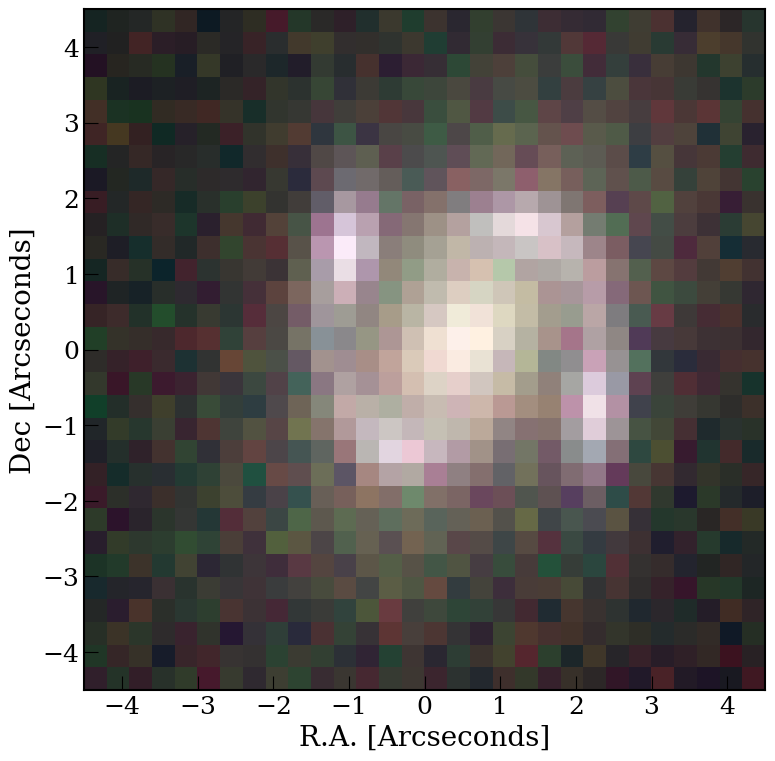

In [232]:
from astropy.visualization import AsinhStretch, MinMaxInterval, LogStretch, ManualInterval, PercentileInterval, SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize

noise_scale = 3e10

R = NIR_J_kwargs_data['image_data']* 1.2 + noiseR * noise_scale
G = NIR_Y_kwargs_data['image_data'] * 1.0 + noiseG * noise_scale
B = (VIS_image) + noiseB * noise_scale

norm = ImageNormalize(stretch=AsinhStretch(), interval=ManualInterval(vmin=.5e-1, vmax=1.9))

Rn = norm(R)
Gn = norm(G)
Bn = norm(B)

rgb = np.dstack((Rn, Gn, Bn))

rgb = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))

cutout_size = 10

rgb_subbed = rgb[cutout_size:-cutout_size, cutout_size:-cutout_size, :]

extent = (-.5*rgb_subbed.shape[0]*NIR_pixel_scale, .5*rgb_subbed.shape[0]*NIR_pixel_scale, -0.5*rgb_subbed.shape[1]*NIR_pixel_scale, 0.5*rgb_subbed.shape[1]*NIR_pixel_scale)

plt.figure(figsize=(8,8))
plt.imshow(rgb_subbed, origin='lower', extent=extent)

plt.xlabel('R.A. [Arcseconds]')
plt.ylabel('Dec [Arcseconds]')
plt.savefig('euclid_simulated_image.png', dpi=300)
plt.show()

In [44]:
# save images to fits files
from astropy.io import fits

def save_image_to_fits(image_data, filename):
    hdu = fits.PrimaryHDU(image_data)
    hdu.writeto(filename, overwrite=True)

save_image_to_fits(VIS_image_resampled, 'lens_source_VIS.fits')
save_image_to_fits(NIR_Y_kwargs_data['image_data'], 'lens_source_NIR_Y.fits')
save_image_to_fits(NIR_J_kwargs_data['image_data'], 'lens_source_NIR_J.fits')
save_image_to_fits(NIR_H_kwargs_data['image_data'], 'lens_source_NIR_H.fits')

In [233]:
# convolve NIR to VIS and upsample using bilinear interpolation

from reproject import reproject_interp
resampled_images = [VIS_kwargs_data['image_data']]
footprints = []

for image in [NIR_Y_kwargs_data['image_data'], NIR_J_kwargs_data['image_data'], NIR_H_kwargs_data['image_data']]:

    image, footprint = reproject_interp((image, NIR_header), VIS_header, order='bilinear')

    resampled_images.append(image)
    footprints.append(footprint)

resampled_images[1].shape, footprints[0].shape

((150, 150), (150, 150))

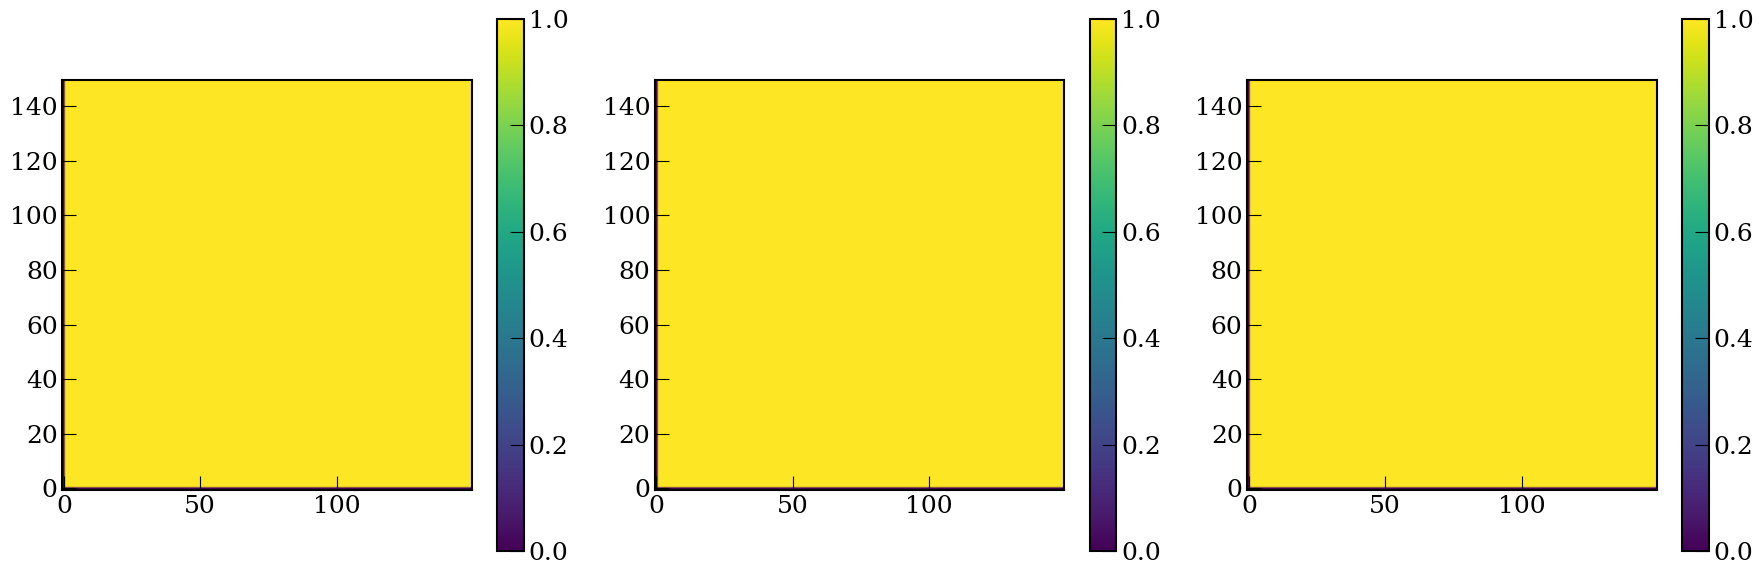

In [234]:
# plot footprints of interperlation for sanity

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    ax.imshow(footprints[i], origin='lower', vmin=0.0, vmax=1.0)
    plt.colorbar(mappable=ax.images[0], ax=ax)

plt.show()

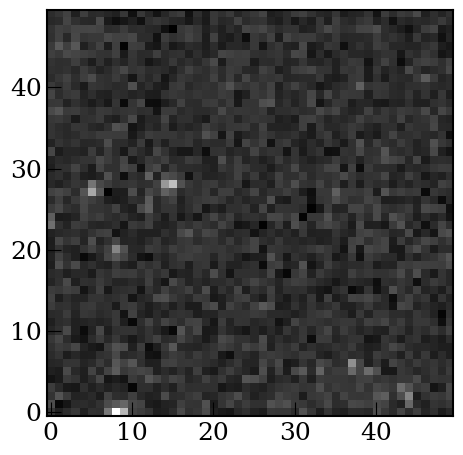

In [235]:
plt.imshow(noise_data['VIS_resampled'], origin='lower', cmap='gray')

In [236]:
noised_images = []
noise_means = []

lower, upper = np.array(noise_data['VIS'].shape) // 2 - VIS_num_pix // 2

for i, filter in enumerate(filters):
    noised_images.append(noise_data[filter][lower:-upper, lower:-upper] + resampled_images[i])
    noise_means.append(np.mean(noise_data[filter]))

noise_means = np.array(noise_means)

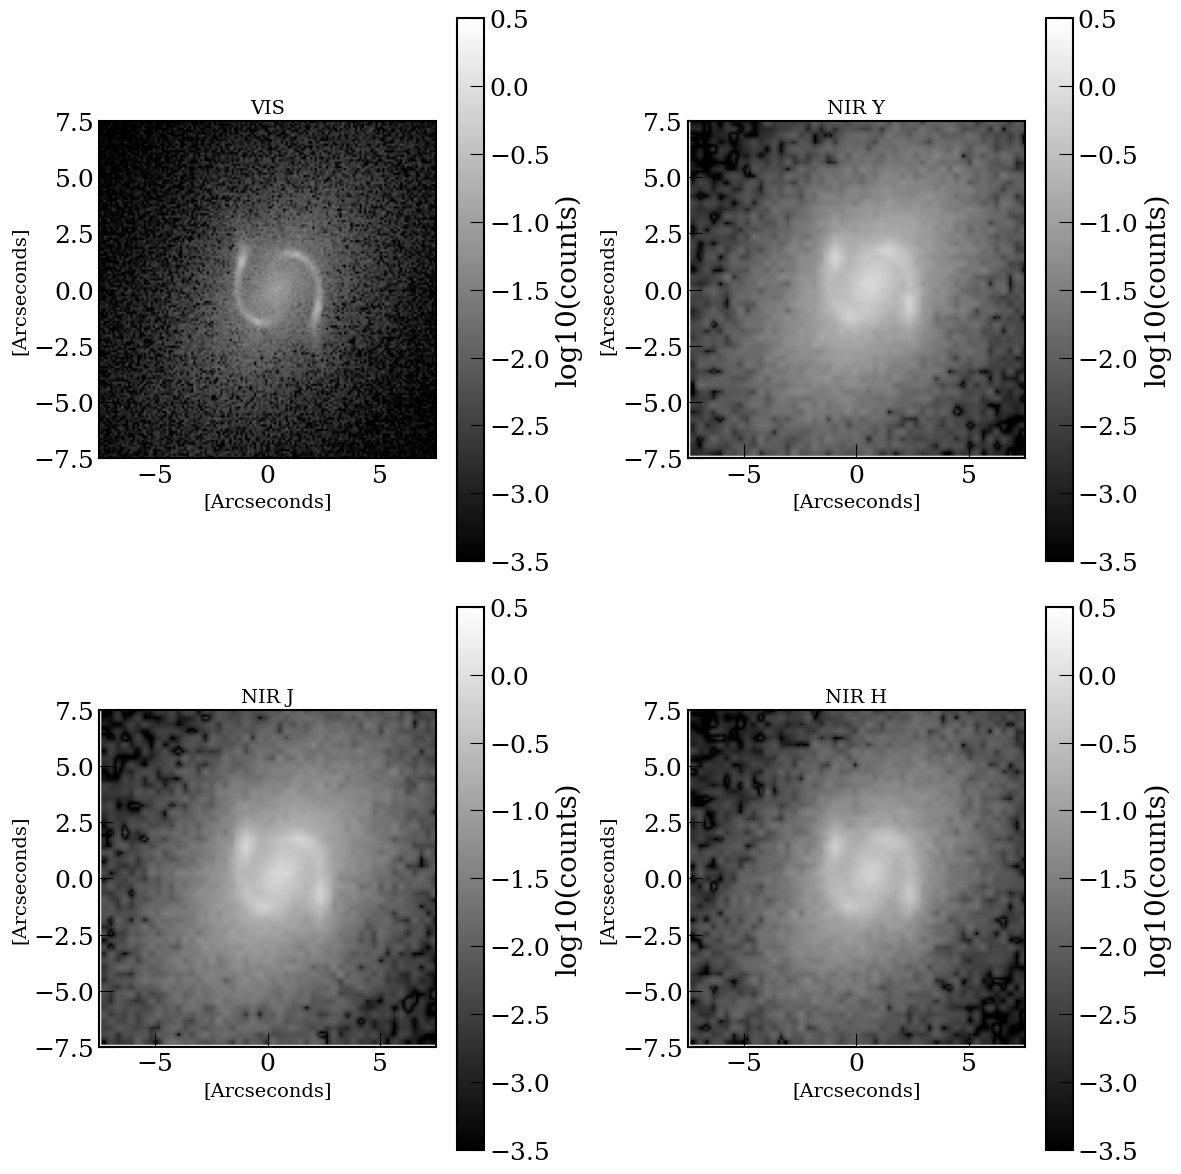

In [237]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

font_size = 14

vmin = -3.5
vmax = 0.5

extent = (-VIS_num_pix*VIS_pixel_scale/2, VIS_num_pix*VIS_pixel_scale/2, -VIS_num_pix*VIS_pixel_scale/2, VIS_num_pix*VIS_pixel_scale/2)

ax = axes[0, 0]
ax.imshow(np.log10(np.abs(resampled_images[0])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('VIS', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[0, 1]
ax.imshow(np.log10(np.abs(resampled_images[1])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR Y', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 0]
ax.imshow(np.log10(np.abs(resampled_images[2])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR J', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 1]
ax.imshow(np.log10(np.abs(resampled_images[3])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR H', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

plt.show()

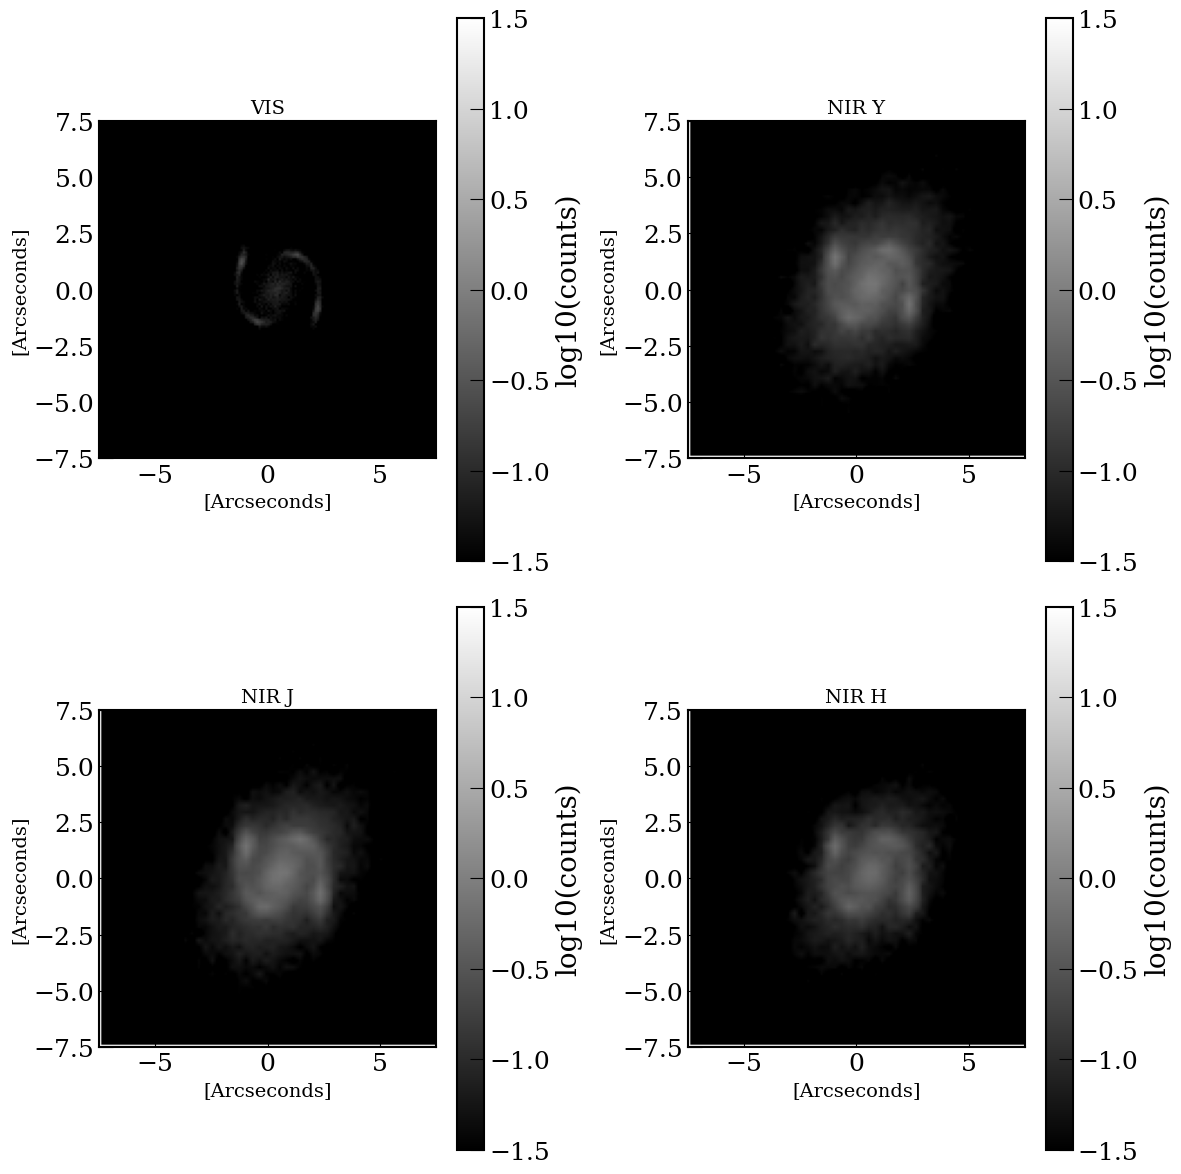

In [238]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

font_size = 14

vmin = -1.5
vmax = 1.5

extent = (-VIS_num_pix*VIS_pixel_scale/2, VIS_num_pix*VIS_pixel_scale/2, -VIS_num_pix*VIS_pixel_scale/2, VIS_num_pix*VIS_pixel_scale/2)

ax = axes[0, 0]
ax.imshow(np.log10(np.abs(noised_images[0])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('VIS', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[0, 1]
ax.imshow(np.log10(np.abs(noised_images[1])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR Y', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 0]
ax.imshow(np.log10(np.abs(noised_images[2])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR J', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

ax = axes[1, 1]
ax.imshow(np.log10(np.abs(noised_images[3])), origin='lower', cmap='grey', vmin=vmin, vmax=vmax, extent=extent)
ax.set_title('NIR H', fontsize=font_size)
ax.set_xlabel('[Arcseconds]', fontsize=font_size)
ax.set_ylabel('[Arcseconds]', fontsize=font_size)
plt.colorbar(mappable=ax.images[0], ax=ax, label='log10(counts)')

plt.show()

In [239]:
from photutils import aperture

center = np.array(VIS_kwargs_data['image_data'].shape) // 2
center[0] += 4
step_size = 3
radii = np.arange(step_size, 40, step_size)

print(noise_means.shape)

apertures = []
areas = []

print(noise_means.shape)

for radius in radii:
    ap = aperture.CircularAperture(center, r=radius)
    apertures.append(ap)
    areas.append(ap.area)

counts_circle = []
for image in noised_images:
    counts_circle.append(np.array([aperture.aperture_photometry(image, ap)['aperture_sum'][0] for ap in apertures]))

counts_annuli = []
areas_annuli = []
for i, filter_count in enumerate(counts_circle):
    counts_annuli.append(np.diff(filter_count))
    counts_annuli[i] = np.insert(counts_annuli[i], 0, counts_circle[i][0])

    areas_annuli.append(np.diff(areas))
    areas_annuli[i] = np.insert(areas_annuli[i], 0, areas[0])

counts_annuli = np.array(counts_annuli)

counts_annuli_per_pix = counts_annuli / areas_annuli# - np.tile(noise_means.reshape(-1,1), radii.shape)
mag_annuli_per_pix = (np.log10(counts_annuli_per_pix))# - np.tile(zeropoints.reshape(-1, 1), radii.shape))

radii.shape, mag_annuli_per_pix.shape

(4,)
(4,)


((13,), (4, 13))

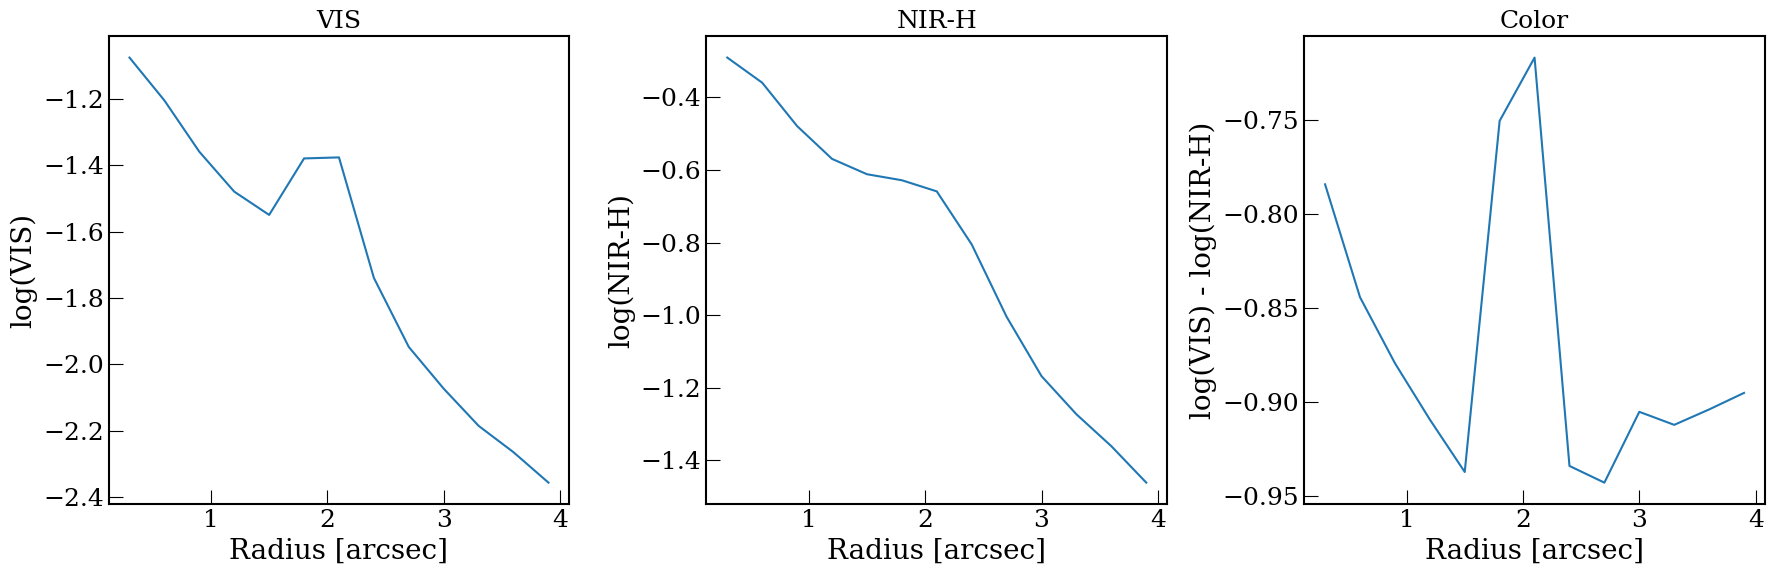

In [240]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

key = {'VIS':0, 'NIR-Y':1, 'NIR-J':2, 'NIR-H':3}

to_plot = ['VIS', 'NIR-H']

ax = axes[0]
ax.plot(radii * VIS_pixel_scale, mag_annuli_per_pix[key[to_plot[0]]])
ax.set_title(to_plot[0])
ax.set_ylabel(fr'log({to_plot[0]})')
ax.set_xlabel('Radius [arcsec]')

ax = axes[1]
ax.plot(radii * VIS_pixel_scale, mag_annuli_per_pix[key[to_plot[1]]])
ax.set_title(to_plot[1])
ax.set_ylabel(fr'log({to_plot[1]})')
ax.set_xlabel('Radius [arcsec]')

ax = axes[2]
ax.plot(radii * VIS_pixel_scale, mag_annuli_per_pix[key[to_plot[0]]] - mag_annuli_per_pix[key[to_plot[1]]])
ax.set_title('Color')
ax.set_ylabel(fr'log({to_plot[0]}) - log({to_plot[1]})')
ax.set_xlabel('Radius [arcsec]')

plt.show()

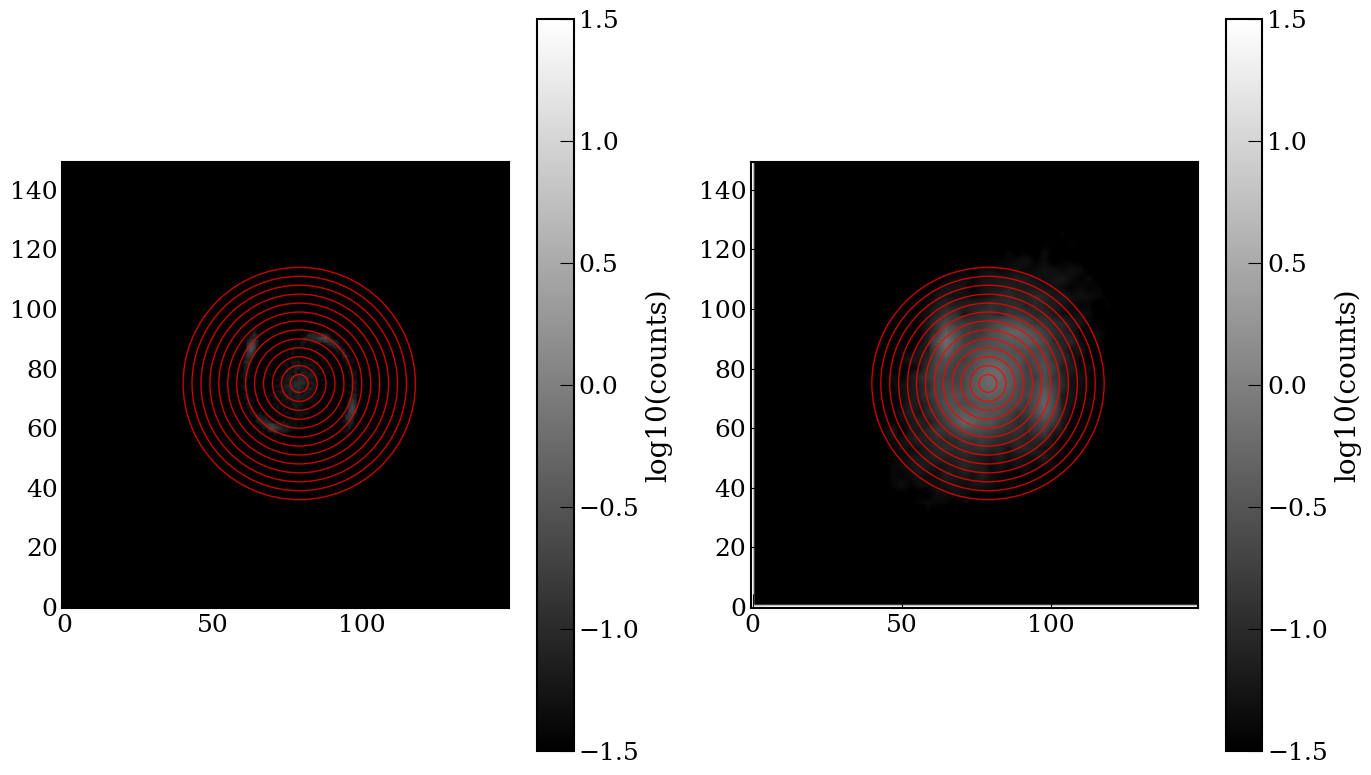

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

ax[0].imshow(np.log10(np.abs(resampled_images[key[to_plot[0]]])), cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
for ap in apertures:
    ap.plot(color='red', alpha=0.8, ax=ax[0])
#ax[0].set_title("F200LP - Convolved to Euclid PSF")
plt.colorbar(mappable=ax[0].images[0], ax=ax[0], label='log10(counts)')

ax[1].imshow(np.log10(np.abs(resampled_images[key[to_plot[1]]])), cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
for ap in apertures:
    ap.plot(color='red', alpha=0.8, ax=ax[1])
plt.colorbar(mappable=ax[1].images[0], ax=ax[1], label='log10(counts)')

plt.show()

In [243]:
# save to fits files
output_directory = f'{cwd}/{input_name}/'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

for i, filter in enumerate(filters):
    hdu = fits.PrimaryHDU([i], header=VIS_header)
    hdu.writeto(output_directory + f'{filter}_image.fits', overwrite=True)

In [244]:
kwargs_params_in

{'kwargs_lens': [{'theta_E': 1.8,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2},
  {'theta_E': 0.4,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104}],
 'kwargs_source': [{'amp': 50.23992760883659,
   'R_sersic': 0.2,
   'n_sersic': 4.0,
   'center_x': 0.4,
   'center_y': 0.0,
   'e1': -0.5,
   'e2': -0.6}],
 'kwargs_lens_light': [{'amp': 4.723571557984374,
   'R_sersic': 2.5,
   'n_sersic': 1.5,
   'center_x': 0.3686891993185043,
   'center_y': -0.040460506267520104,
   'e1': -0.1,
   'e2': 0.2}],
 'kwargs_ps': [],
 'kwargs_special': {},
 'kwargs_extinction': [],
 'kwargs_tracer_source': []}